# Tokenisation


In [ ]:
text = "The people who are crazy enough to think they can change the world are the ones who do."

**tiktoken**

In [ ]:
pip install tiktoken

In [ ]:
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-4.1")

# Token IDs
token_ids = encoding.encode(text)

print("Token IDs:")
print(token_ids)

print("\nIndividual Tokens:")
for token_id in token_ids:
    token = encoding.decode([token_id])
    print(f"{token_id:<8} {repr(token)}")

print("\nTotal Tokens:", len(token_ids))

Token IDs:
[976, 1665, 1218, 553, 21528, 4951, 316, 2411, 1023, 665, 3343, 290, 2375, 553, 290, 8104, 1218, 621, 13]

Individual Tokens:
976      'The'
1665     ' people'
1218     ' who'
553      ' are'
21528    ' crazy'
4951     ' enough'
316      ' to'
2411     ' think'
1023     ' they'
665      ' can'
3343     ' change'
290      ' the'
2375     ' world'
553      ' are'
290      ' the'
8104     ' ones'
1218     ' who'
621      ' do'
13       '.'

Total Tokens: 19


**huggingface**

In [ ]:
pip install transformers sentencepiece torch

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "gpt2"
)

# Token IDs
token_ids = tokenizer.encode(text)

print("Token IDs:")
print(token_ids)

print("\nIndividual Tokens:")

tokens = tokenizer.convert_ids_to_tokens(token_ids)

for token_id, token in zip(token_ids, tokens):
    print(f"{token_id:<8} {repr(token)}")

print("\nTotal Tokens:", len(token_ids))

Token IDs:
[464, 661, 508, 389, 7165, 1576, 284, 892, 484, 460, 1487, 262, 995, 389, 262, 3392, 508, 466, 13]

Individual Tokens:
464      'The'
661      'Ġpeople'
508      'Ġwho'
389      'Ġare'
7165     'Ġcrazy'
1576     'Ġenough'
284      'Ġto'
892      'Ġthink'
484      'Ġthey'
460      'Ġcan'
1487     'Ġchange'
262      'Ġthe'
995      'Ġworld'
389      'Ġare'
262      'Ġthe'
3392     'Ġones'
508      'Ġwho'
466      'Ġdo'
13       '.'

Total Tokens: 19


https://huggingface.co/openai-community/gpt2/tree/main

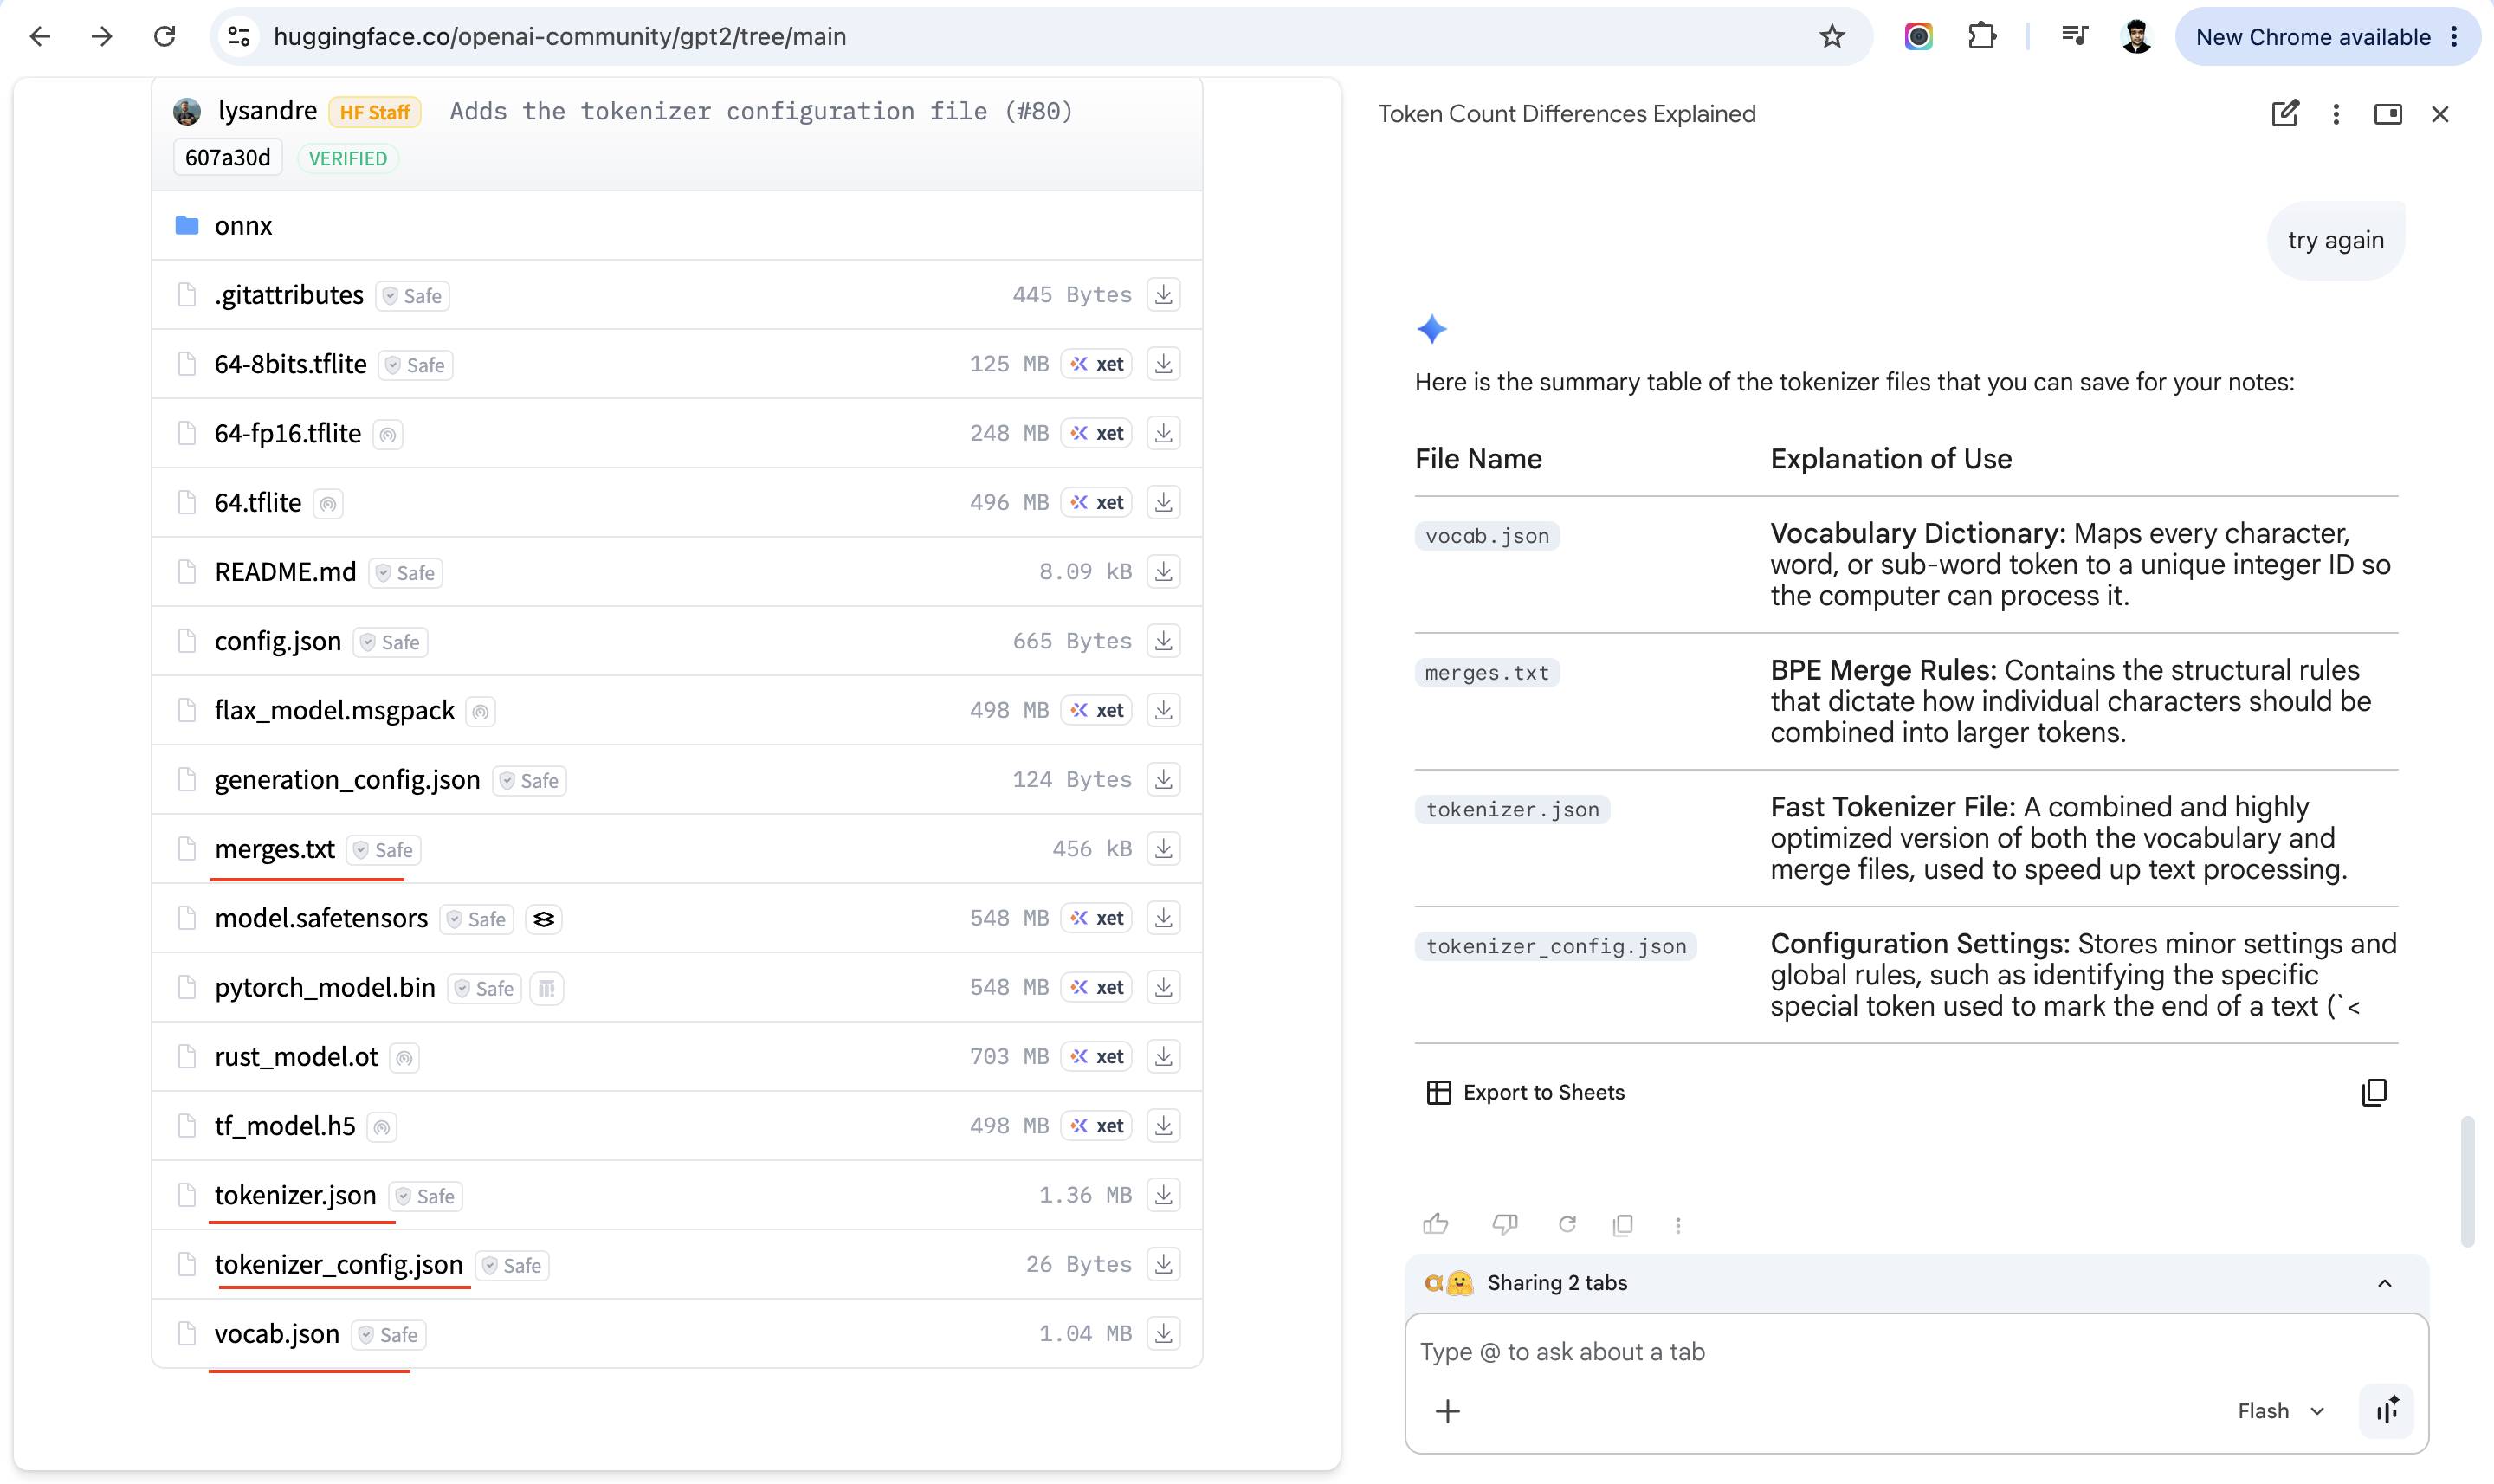

**SentencePiece**

In [29]:
import sentencepiece as spm

# 1. Create a quick mock text file inside Colab to train on
with open("colab_test.txt", "w") as f:
    f.write(text)

# 2. Train a small sentencepiece model (setting a small vocabulary size of 36)
spm.SentencePieceTrainer.train(input='colab_test.txt', model_prefix='my_tokenizer', vocab_size=32)

# 3. Load your freshly trained custom tokenizer
sp = spm.SentencePieceProcessor(model_file='my_tokenizer.model')

# 4. Test it!
text = "I'm a recruiter. Not a developer, not an engineer."
print("SentencePiece IDs:", sp.encode_as_ids(text))
print("SentencePiece Tokens:", sp.encode_as_pieces(text))
print("\nTotal Tokens:", len(sp.encode_as_pieces(text)))

SentencePiece IDs: [5, 0, 5, 9, 5, 7, 4, 29, 7, 22, 21, 31, 4, 7, 23, 5, 0, 3, 31, 5, 9, 5, 13, 4, 0, 4, 15, 3, 16, 4, 7, 0, 5, 8, 3, 31, 5, 18, 5, 4, 8, 14, 21, 8, 4, 4, 7, 23]
SentencePiece Tokens: ['▁', "I'm", '▁', 'a', '▁', 'r', 'e', 'c', 'r', 'u', 'i', 't', 'e', 'r', '.', '▁', 'N', 'o', 't', '▁', 'a', '▁', 'd', 'e', 'v', 'e', 'l', 'o', 'p', 'e', 'r', ',', '▁', 'n', 'o', 't', '▁', 'an', '▁', 'e', 'n', 'g', 'i', 'n', 'e', 'e', 'r', '.']

Total Tokens: 48
